# A Global Species-Richness Map

This raster visualization example builds a publication-style global map of species richness on an
equal-area projection, with zoomed-in inset panels for individual regions. It pulls together
rasterio, an equal-area CRS, masked `imshow`, an inset colorbar, and coordinate transforms.

```{admonition} This page is a runnable notebook
:class: tip
Read it here, or click the launch button (*"Open in Colab"*) at the top of the page to run
it yourself. It uses the bundled **10 km** grid; the full study uses a 1 km grid (the
optional Zenodo download in [](../appendix/data.md)) for sharper zoom-ins.
```


## 0 · Setup

In [ ]:
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip -q install rasterio geopandas cartopy
    import urllib.request
    BASE = "https://raw.githubusercontent.com/tongyuanwu/spatial-tutorial/main/book/data"
    os.makedirs("data/world_map", exist_ok=True)
    urllib.request.urlretrieve(f"{BASE}/species_richness_10km_eck4.tif", "data/species_richness_10km_eck4.tif")
    for ext in ["shp", "shx", "dbf", "prj"]:
        urllib.request.urlretrieve(f"{BASE}/world_map/world_map.{ext}", f"data/world_map/world_map.{ext}")

def find_data_dir(start=None):
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "data").is_dir():
            return p / "data"
    return Path("data")

DATA_DIR = find_data_dir()
print("Using DATA_DIR =", DATA_DIR)

In [2]:
import numpy as np
import rasterio as rio
import geopandas as gpd
from pyproj import Transformer
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

## 1 · Load the species-richness grid

The raster is already in the **Eckert IV** equal-area projection (`ESRI:54012`). We read the
single band, read the country outlines, and reproject them to the same CRS.


In [3]:
src = rio.open(DATA_DIR / "species_richness_10km_eck4.tif")
sr = src.read(1)
vmax = int(sr.max())

world = gpd.read_file(DATA_DIR / "world_map" / "world_map.shp").to_crs(src.crs)

left, bottom, right, top = src.bounds.left, src.bounds.bottom, src.bounds.right, src.bounds.top
extent = [left, right, bottom, top]
print("grid:", sr.shape, "| max richness:", vmax, "| CRS:", src.crs.to_string())

grid: (1694, 3386) | max richness: 871 | CRS: ESRI:54012


## 2 · The main map

We mask out the zero background with `np.where(sr > 0, sr, np.nan)` so empty cells stay
transparent, draw the raster with `extent` so it registers under the country outlines, and
add a small horizontal **inset colorbar**.


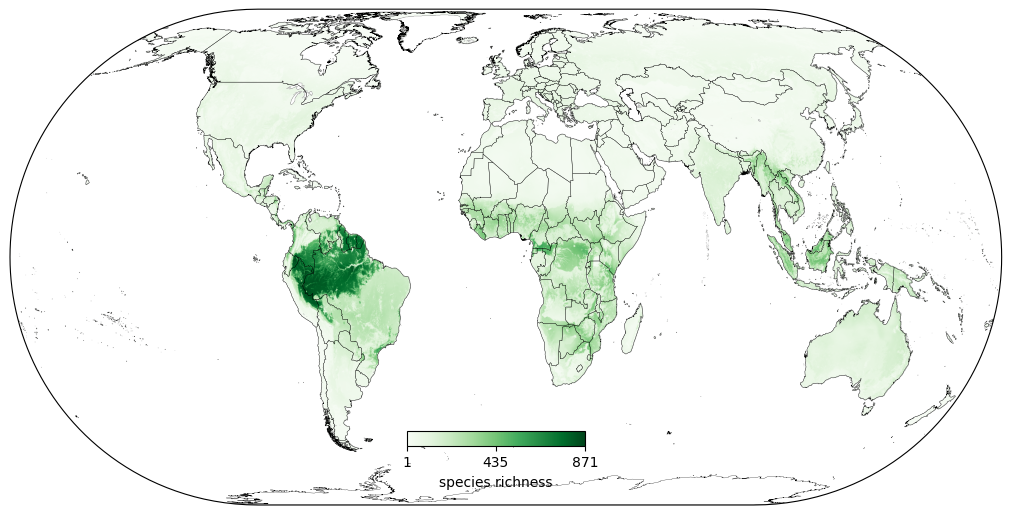

In [4]:
fig = plt.figure(figsize=(10, 6), constrained_layout=True)
ax = plt.subplot(1, 1, 1, projection=ccrs.EckertIV())

im = ax.imshow(np.where(sr > 0, sr, np.nan), cmap="Greens", vmin=1, vmax=vmax,
               origin="upper", extent=extent, zorder=1)
world.plot(ax=ax, color="none", edgecolor="black", lw=0.2, zorder=2)

cax = ax.inset_axes([0.40, 0.12, 0.18, 0.03])
cbar = fig.colorbar(im, cax=cax, orientation="horizontal", label="species richness")
cbar.set_ticks([1, vmax // 2, vmax])
plt.show()

## 3 · Zoom-in panels

To inspect a region, we convert its lon/lat to the raster's CRS, invert the affine transform
to get a pixel `(row, col)`, and slice a window straight out of the array. A small helper
draws one zoom panel; we place several with `inset_axes`.


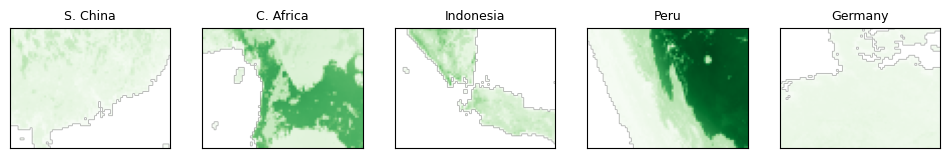

In [5]:
transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)

def draw_zoom_in(lon, lat, axx, hw=40, hh=30):
    x, y = transformer.transform(lon, lat)
    col, row = ~src.transform * (x, y)
    col, row = int(col), int(row)
    win = sr[max(row - hh, 0):row + hh, max(col - hw, 0):col + hw]
    axx.imshow(np.where(win > 0, win, np.nan), cmap="Greens", vmin=1, vmax=vmax)
    axx.set_xticks([]); axx.set_yticks([])

regions = [(113.5, 23, "S. China"), (11, 3, "C. Africa"), (106, -6, "Indonesia"),
           (-75, -10, "Peru"), (10, 53, "Germany")]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, (lon, lat, name) in zip(axes, regions):
    draw_zoom_in(lon, lat, ax)
    ax.set_title(name, fontsize=9)
plt.show()

## 4 · Putting it together

The publication figure combines the global map with the regional insets in one panel — the
main map labelled **a**, the zoom-ins **b–f**.


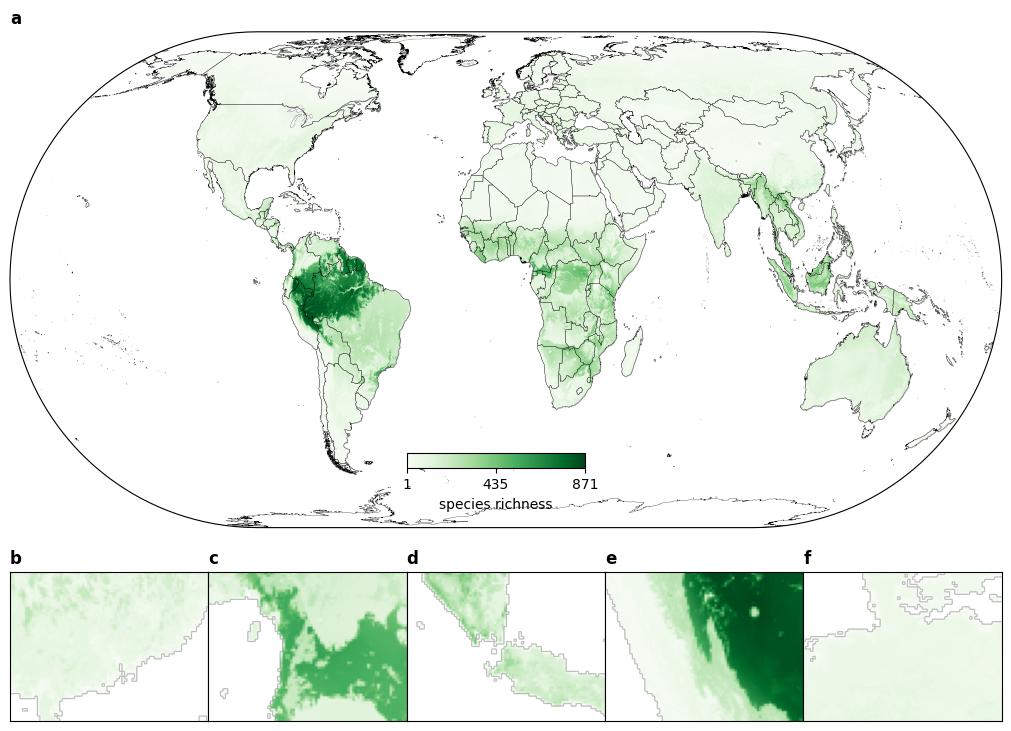

In [6]:
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax1 = plt.subplot(1, 1, 1, projection=ccrs.EckertIV())

im = ax1.imshow(np.where(sr > 0, sr, np.nan), cmap="Greens", vmin=1, vmax=vmax,
                origin="upper", extent=extent, zorder=1)
world.plot(ax=ax1, color="none", edgecolor="black", lw=0.2, zorder=2)

cax = ax1.inset_axes([0.40, 0.12, 0.18, 0.03])
cbar = fig.colorbar(im, cax=cax, orientation="horizontal", label="species richness")
cbar.set_ticks([1, vmax // 2, vmax])
ax1.set_title("a", loc="left", fontweight="semibold")

labels = ["b", "c", "d", "e", "f"]
for k, (lon, lat, name) in enumerate(regions):
    axk = ax1.inset_axes([k * 0.20, -0.42, 0.20, 0.36])
    draw_zoom_in(lon, lat, axk)
    axk.set_title(labels[k], loc="left", fontweight="semibold")
plt.show()

```{admonition} Deliverable
:class: note
A publication-style Eckert IV species-richness map with an inset colorbar and five regional
zoom-in panels — built entirely from the bundled 10 km grid.
```
